In [1]:
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.model_selection import train_test_split

import torch
from torch.utils.data import DataLoader, TensorDataset

from split.create_split import create_split
from models.random_forest import RandomForestPredictor
from main_scorer import plot_results, plot_umap_embedding
from models.oracle import build_oracle_df, oracle_lookup
from models.lstm_goaldirected import LSTMGoalDirected
from models import mlp_oracle

SEED = 42

/Users/meier/Documents/PracticalWork/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/meier/Documents/PracticalWork/.venv/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Train LSTM with Reniforcement Learning - TFBind8

In [2]:
# Load dataset: TFBIND 8 - SIX6 REF R1
df = pd.read_csv('tf_bind_8-SIX6_REF_R1/dataset.csv')

# Add a column encoded sequence instead of the cols 0-7
df['encoded_sequence'] = df.apply(lambda row: [row[str(i)] for i in range(8)], axis=1)
df['split'] = ['None'] * len(df)

# Create train/test splits
df = create_split(df, k_seeds=50, n_training_seeds=20, random_state=42)

# Prepare training data
train_df = df[df['split'] == 'train']
x = train_df.iloc[:, :-6].values
y = train_df['binding_scores'].values
# One-hot encode and reshape to 3D for LSTM (samples, timesteps, features)
x_one_hot = np.array([tf.one_hot(seq, depth=4).numpy() for seq in x])
X_train, X_val, y_train, y_val = train_test_split(x, y, test_size=0.1, random_state=SEED)
# check sizes of testsplits
df['split'].value_counts()

split
test_c    38796
test_a    10614
train      8670
test_b     7712
Name: count, dtype: int64

In [3]:
rf = RandomForestPredictor()
rf.train(X_train, y_train)
rf.evaluate(X_val, y_val)

Training Random Forest model...
Training completed.
R2 Score: 0.1591811679216245
MSE: 0.004913541466129368
Spearman Correlation: 0.3804121548809125


{'r2': 0.1591811679216245,
 'mse': 0.004913541466129368,
 'spearman_correlation': np.float64(0.3804121548809125)}

In [4]:
X_train_tensor = torch.LongTensor(X_train)
y_train_tensor = torch.FloatTensor(y_train).view(-1, 1)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

In [5]:
def train_goal_directed_model(model, loader, epochs=20, lr= 0.001):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = torch.nn.CrossEntropyLoss()

    model.train()

    for epoch in range(epochs):
        epoch_loss = 0
        for batch_x, batch_y in loader:
            optimizer.zero_grad()

            input = batch_x[:, :-1]
            target_part = batch_x[:, 1:]
            logits, _ = model(input, batch_y)
            loss = criterion(logits.reshape(-1, model.vocab_size), target_part.reshape(-1))

            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()
        if epoch+1 % 5 == 0:
            print(f'Epoch {epoch+1}/{epochs}, Loss: {epoch_loss/len(loader)}')

#### Iterative Feedback Loop with retraining

In [6]:
def rl_loop(model, scorer, oracle, num_iterations=6, batch_size = 128, X_train=None, y_train=None, GB1=False):
    values = {'mutation': [], 'predicted_score': [], 'real_score': []}
    for i in range(num_iterations):
        print(f'-------- Iteration {i+1}/{num_iterations} --------')
        
        ### Propose new sequences
        new_sequences = []
        for _ in range(batch_size):
            seq = model.generate(goal_score=1.1, temp = 0.8)
            new_sequences.append(seq)

        new_sequences_np = np.array(new_sequences)
        
        ### Score new sequences by RF
        scores = []
        for seq in new_sequences_np:
            scores.append(scorer.predict(seq))

        scores = np.array(scores)

        ### Lookup oracle for real scores
        real_scores = []
        for seq in new_sequences_np:
            if GB1:
                seq_one_hot = tf.one_hot(seq, depth=20).numpy()
                real_score = oracle.inference(torch.tensor(seq_one_hot.flatten(), dtype=torch.float32)).item()
            
            else:
                real_score = oracle_lookup(oracle, seq)
            real_scores.append(real_score)

        real_scores_np = np.array(real_scores)

        ### Select top 20% sequences based on real scores
        threshold = np.percentile(real_scores, 80)
        top_sequences = new_sequences_np[real_scores_np >= threshold]
        top_scores = scores[real_scores_np >= threshold]
        top_real_scores = real_scores_np[real_scores_np >= threshold]

        print(f'Average score of proposed: {np.mean(scores):.4f}, Averagle real score: {np.mean(real_scores_np):.4f}, Average score of top 20%: {np.mean(top_scores):.4f}')

        # Append for plotting
        values['mutation'].extend(top_sequences)
        values['predicted_score'].extend(top_scores)
        values['real_score'].extend(top_real_scores)
        
        # Update LSTM model with top sequences
        x_train_tensor = torch.LongTensor(top_sequences)
        y_train_tensor = torch.FloatTensor(top_scores).view(-1, 1)

        dataloader = DataLoader(TensorDataset(x_train_tensor, y_train_tensor), batch_size=16, shuffle=True)
        train_goal_directed_model(model, dataloader, epochs=20, lr=0.001)


    return values

### Improved RF Loop:
- added a diversity filtering for selected sequences for retraining: hamming distance need to be larger than a threshold
- training data is now mixed with original training data (prevention of forgetting)
- entropy is regularized: low-entropy output is penalized during training
- temperature is increasing over iterations to have more exploration

this should prevent the approach from suggesting always the same sequence after a couple of steps. 

In [7]:
def train_goal_directed_model_v2(model, loader, epochs=20, lr=0.001, entropy_weight=0.01):
    """Training with entropy regularization to prevent mode collapse."""
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = torch.nn.CrossEntropyLoss()

    model.train()

    for epoch in range(epochs):
        epoch_loss = 0
        for batch_x, batch_y in loader:
            optimizer.zero_grad()

            input = batch_x[:, :-1]
            target_part = batch_x[:, 1:]
            logits, _ = model(input, batch_y)
            ce_loss = criterion(logits.reshape(-1, model.vocab_size), target_part.reshape(-1))

            # Entropy regularization: encourage diverse token predictions
            # penalize low-entropy output distris during training to prevent mode collapse
            probs = torch.softmax(logits, dim=-1)
            entropy = -(probs * torch.log(probs + 1e-8)).sum(dim=-1).mean()
            loss = ce_loss - entropy_weight * entropy  # maximize entropy

            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()
        if epoch % 5 == 0:
            print(f'Epoch {epoch}/{epochs}, Loss: {epoch_loss/len(loader):.4f}')


def diversity_filter(sequences, scores, real_scores, min_hamming=2):
    """Greedily pick sequences that are at least min_hamming apart."""
    selected_idx = [0]
    for i in range(1, len(sequences)):
        is_diverse = True
        for j in selected_idx:
            dist = np.sum(sequences[i] != sequences[j])
            if dist < min_hamming:
                is_diverse = False
                break
        if is_diverse:
            selected_idx.append(i)
    idx = np.array(selected_idx)
    return sequences[idx], scores[idx], real_scores[idx]


def rl_loop_v2(model, scorer, oracle, num_iterations=6, batch_size=128,
               X_train=None, y_train=None, GB1=False,
               min_hamming=2, replay_fraction=0.3, temp_start=0.8, temp_end=1.5,
               entropy_weight=0.01):
    """Improved RL loop"""
    values = {'mutation': [], 'predicted_score': [], 'real_score': []}
    
    # Keep original training data for replay
    replay_x = torch.LongTensor(X_train)
    replay_y = torch.FloatTensor(y_train).view(-1, 1)
    
    for i in range(num_iterations):
        # Anneal temperature: increase over iterations to maintain exploration
        temp = temp_start + (temp_end - temp_start) * (i / max(num_iterations - 1, 1))
        print(f'-------- Iteration {i+1}/{num_iterations} (temp={temp:.2f}) --------')
        
        ### Propose new sequences
        new_sequences = []
        for _ in range(batch_size):
            seq = model.generate(goal_score=1.1, temp=temp)
            new_sequences.append(seq)

        new_sequences_np = np.array(new_sequences)
        
        ### Score new sequences by RF
        scores = np.array([scorer.predict(seq) for seq in new_sequences_np])

        ### Lookup oracle for real scores
        real_scores = []
        for seq in new_sequences_np:
            if GB1:
                seq_one_hot = tf.one_hot(seq, depth=20).numpy()
                real_score = oracle.inference(torch.tensor(seq_one_hot.flatten(), dtype=torch.float32)).item()
            else:
                real_score = oracle_lookup(oracle, seq)
            real_scores.append(real_score)
        real_scores_np = np.array(real_scores)

        ### Select top 20% sequences based on real scores
        threshold = np.percentile(real_scores_np, 80)
        top_mask = real_scores_np >= threshold
        top_sequences = new_sequences_np[top_mask]
        top_scores = scores[top_mask]
        top_real_scores = real_scores_np[top_mask]

        ### Diversity filter: remove near-duplicates
        if len(top_sequences) > 1:
            top_sequences, top_scores, top_real_scores = diversity_filter(
                top_sequences, top_scores, top_real_scores, min_hamming=min_hamming
            )

        n_unique = len(top_sequences)
        print(f'Avg proposed: {np.mean(scores):.4f}, Avg real: {np.mean(real_scores_np):.4f}, '
              f'Top 20% avg: {np.mean(top_scores):.4f}, Unique diverse: {n_unique}')

        # Append for plotting
        values['mutation'].extend(top_sequences)
        values['predicted_score'].extend(top_scores)
        values['real_score'].extend(top_real_scores)
        
        #mix new top sequences with original training data
        x_new = torch.LongTensor(top_sequences)
        y_new = torch.FloatTensor(top_scores).view(-1, 1)
        
        n_replay = int(len(x_new) * replay_fraction / (1 - replay_fraction))
        n_replay = min(n_replay, len(replay_x))
        replay_idx = torch.randperm(len(replay_x))[:n_replay]
        
        x_combined = torch.cat([x_new, replay_x[replay_idx]])
        y_combined = torch.cat([y_new, replay_y[replay_idx]])
        
        dataloader = DataLoader(TensorDataset(x_combined, y_combined), batch_size=16, shuffle=True)
        train_goal_directed_model_v2(model, dataloader, epochs=20, lr=0.001, entropy_weight=entropy_weight)

    return values

Epoch 0/50, Loss: 1.3417
Epoch 5/50, Loss: 1.2987
Epoch 10/50, Loss: 1.2753
Epoch 15/50, Loss: 1.2598
Epoch 20/50, Loss: 1.2496
Epoch 25/50, Loss: 1.2414
Epoch 30/50, Loss: 1.2339
Epoch 35/50, Loss: 1.2278
Epoch 40/50, Loss: 1.2222
Epoch 45/50, Loss: 1.2168
Training Random Forest model...
Training completed.
R2 Score: 0.1591811679216245
MSE: 0.004913541466129368
Spearman Correlation: 0.3804121548809125
-------- Iteration 1/6 (temp=0.80) --------
Avg proposed: 0.3601, Avg real: 0.6620, Top 20% avg: 0.3608, Unique diverse: 22
Epoch 0/20, Loss: 2.1146
Epoch 5/20, Loss: 1.4046
Epoch 10/20, Loss: 1.1900
Epoch 15/20, Loss: 1.0818
-------- Iteration 2/6 (temp=0.94) --------
Avg proposed: 0.3642, Avg real: 0.8160, Top 20% avg: 0.3652, Unique diverse: 4
Epoch 0/20, Loss: 0.9822
Epoch 5/20, Loss: 0.7080
Epoch 10/20, Loss: 0.5726
Epoch 15/20, Loss: 0.4857
-------- Iteration 3/6 (temp=1.08) --------
Avg proposed: 0.3654, Avg real: 0.8610, Top 20% avg: 0.3585, Unique diverse: 7
Epoch 0/20, Loss: 0.

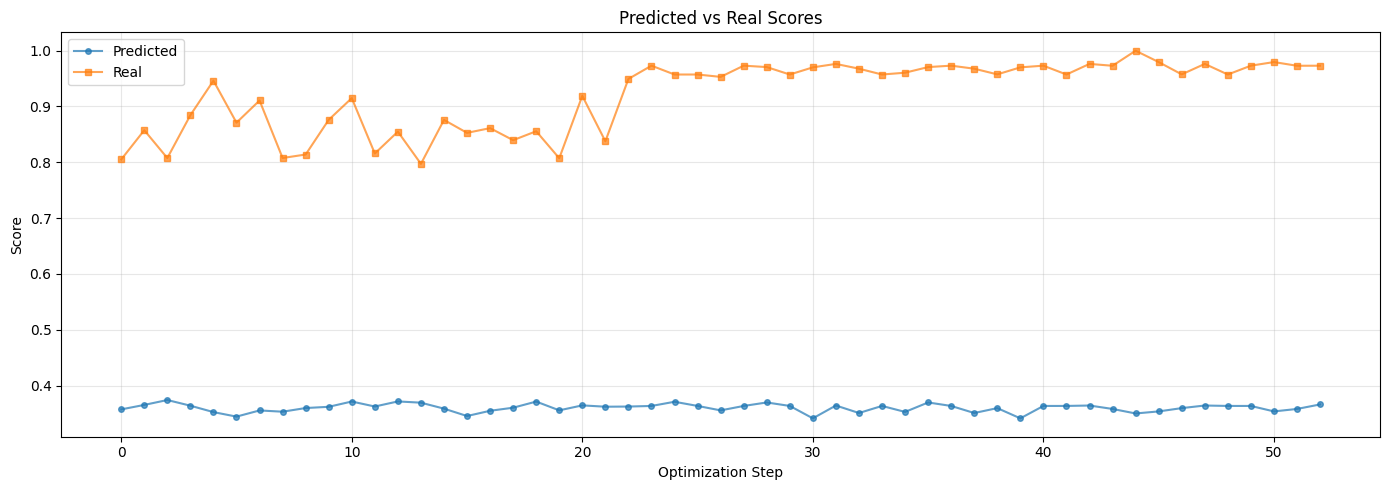

In [8]:
model = LSTMGoalDirected(vocab_size=4, embedding_dim=16, seq_len=8, hidden_dim=64)
#First train the model on the original trianing data
train_goal_directed_model_v2(model, train_loader, epochs=50, lr=0.001)

rf = RandomForestPredictor()
rf.train(X_train, y_train)
rf.evaluate(X_val, y_val)

oracle = build_oracle_df(df)

values = rl_loop_v2(model, rf, oracle, num_iterations=6, batch_size=128, X_train=X_train, y_train=y_train)
values_df = pd.DataFrame(values)
values_df.head()
plot_results(values_df)

Spearman Correlation: -0.1401


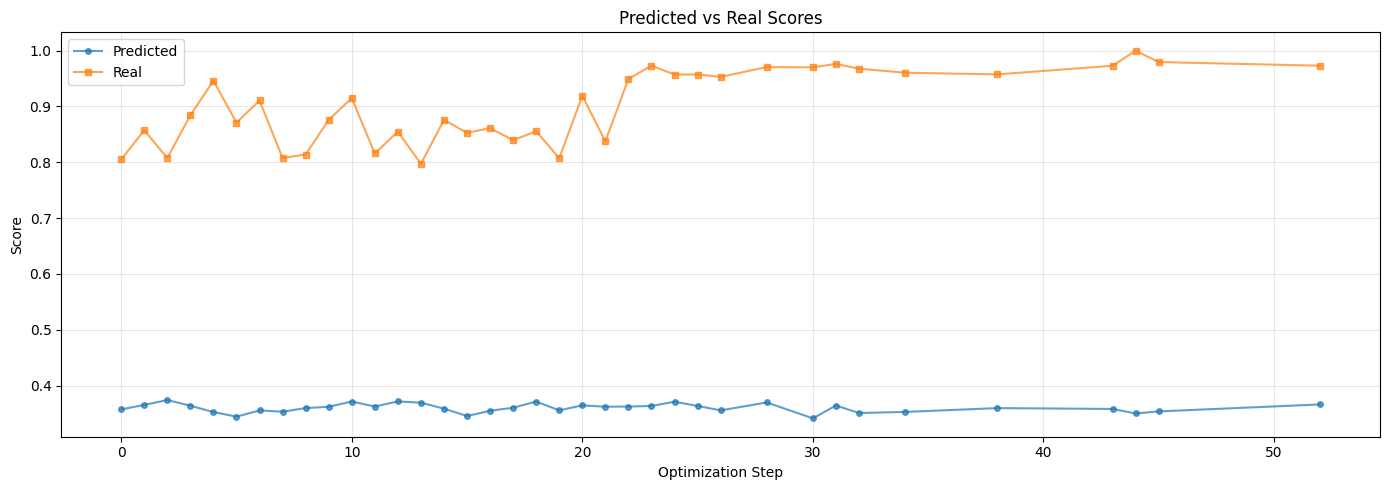

In [9]:
values_copy = values_df.copy()
values_copy['_seq_tuple'] = values_copy['mutation'].apply(lambda seq: tuple(seq))
values_copy.drop_duplicates(subset=['_seq_tuple'], inplace=True)

plot_results(values_copy)

In [10]:
from models.oracle import oracle_lookup

def lookup_oracle_testset(values, oracle):
    """ Look up real scores in generated sequences. If not found, drop the row. """
    drop_cont = 0
    scores = []
    for seq in values['mutation']:
        score = oracle_lookup(oracle, seq)
        if score is not None and score > 0.0:
            scores.append(score)
        else:
            scores.append(np.nan)
            drop_cont += 1
    print(f'Number of sequences not found in oracle: {drop_cont}')
    values['real_score'] = scores
    return values


Number of sequences not found in oracle: 42
Spearman Correlation: -0.3333


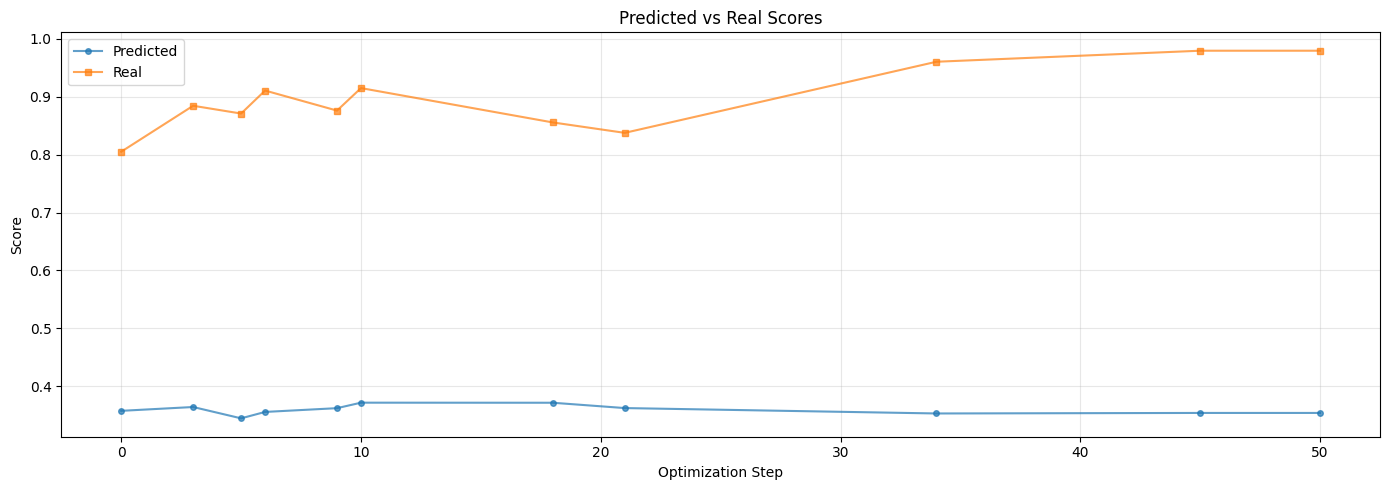

In [11]:
values_copy = values_df.copy()
values_copy.drop(columns=['real_score'], errors='ignore', inplace=True) # Drop real_score if it already exists to avoid confusion
test_a_oracle = build_oracle_df(df[df['split'] == 'test_a'])
test_a_df = lookup_oracle_testset(values_copy, test_a_oracle)
# drop rows with NaN real_score (sequences not found in oracle)
test_a_df = test_a_df.dropna(subset=['real_score'], inplace=False)
plot_results(test_a_df)

/var/folders/_2/6p52z75d21dc91tc6ss7n6w80000gn/T/ipykernel_5198/339187500.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_a_df['mutation'] = test_a_df['mutation'].apply(
/Users/meier/Documents/PracticalWork/.venv/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


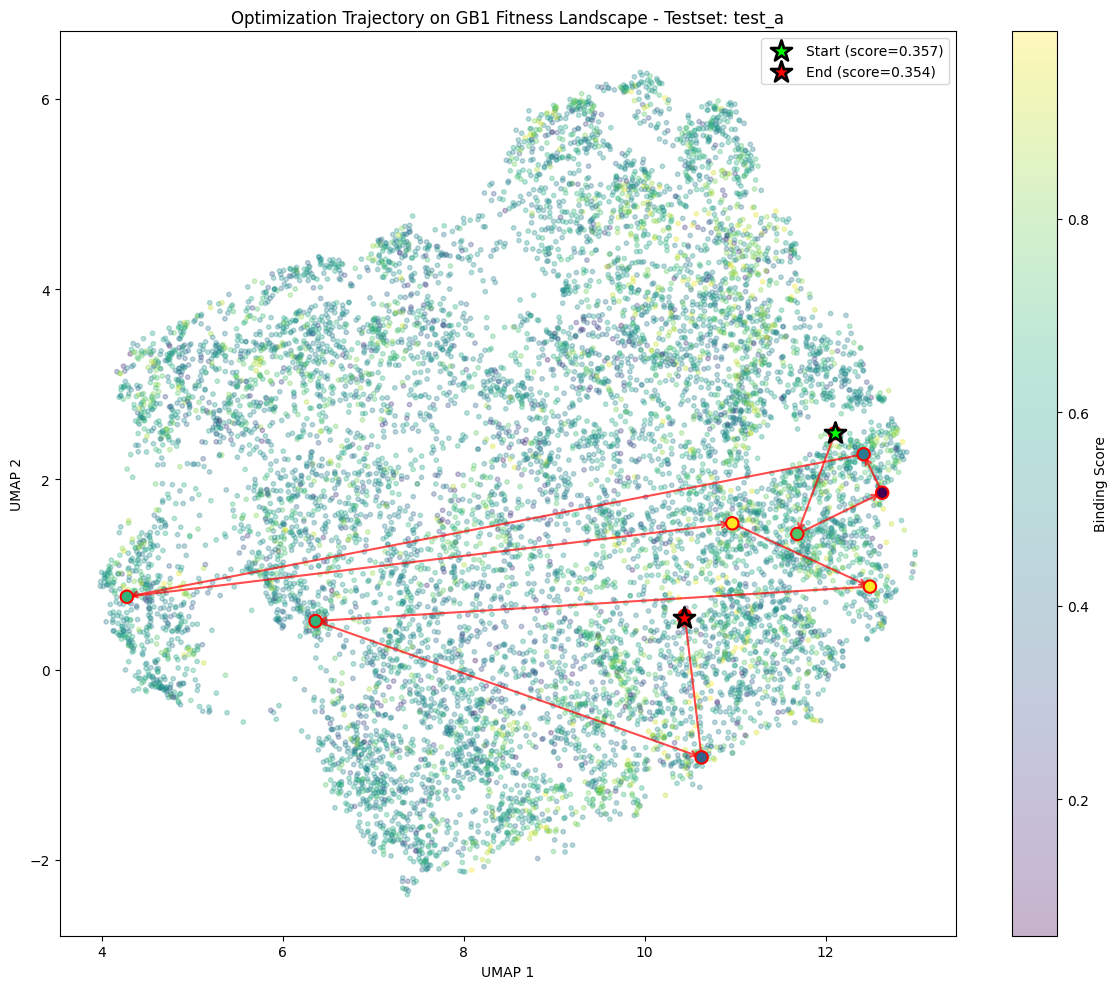

In [12]:
test_a_df['mutation'] = test_a_df['mutation'].apply(
    lambda seq: tf.one_hot(list(seq), depth=4).numpy().flatten()
)

plot_umap_embedding(df, 'test_a', test_a_df, vocab_size=4)

Number of sequences not found in oracle: 44
Spearman Correlation: 0.1826


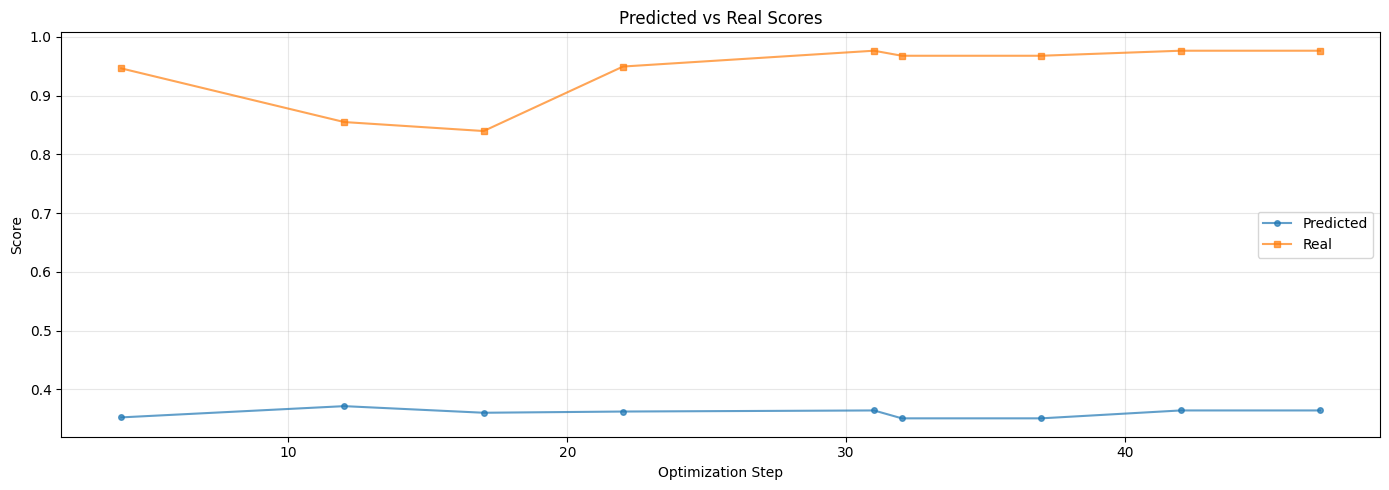

In [13]:
values_copy = values_df.copy()
values_copy.drop(columns=['real_score'], errors='ignore', inplace=True) # Drop real_score if it already exists to avoid confusion
test_b_oracle = build_oracle_df(df[df['split'] == 'test_b'])
test_b_df = lookup_oracle_testset(values_copy, test_b_oracle)
# drop rows with NaN real_score (sequences not found in oracle)
test_b_df = test_b_df.dropna(subset=['real_score'], inplace=False)
plot_results(test_b_df)

/Users/meier/Documents/PracticalWork/.venv/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


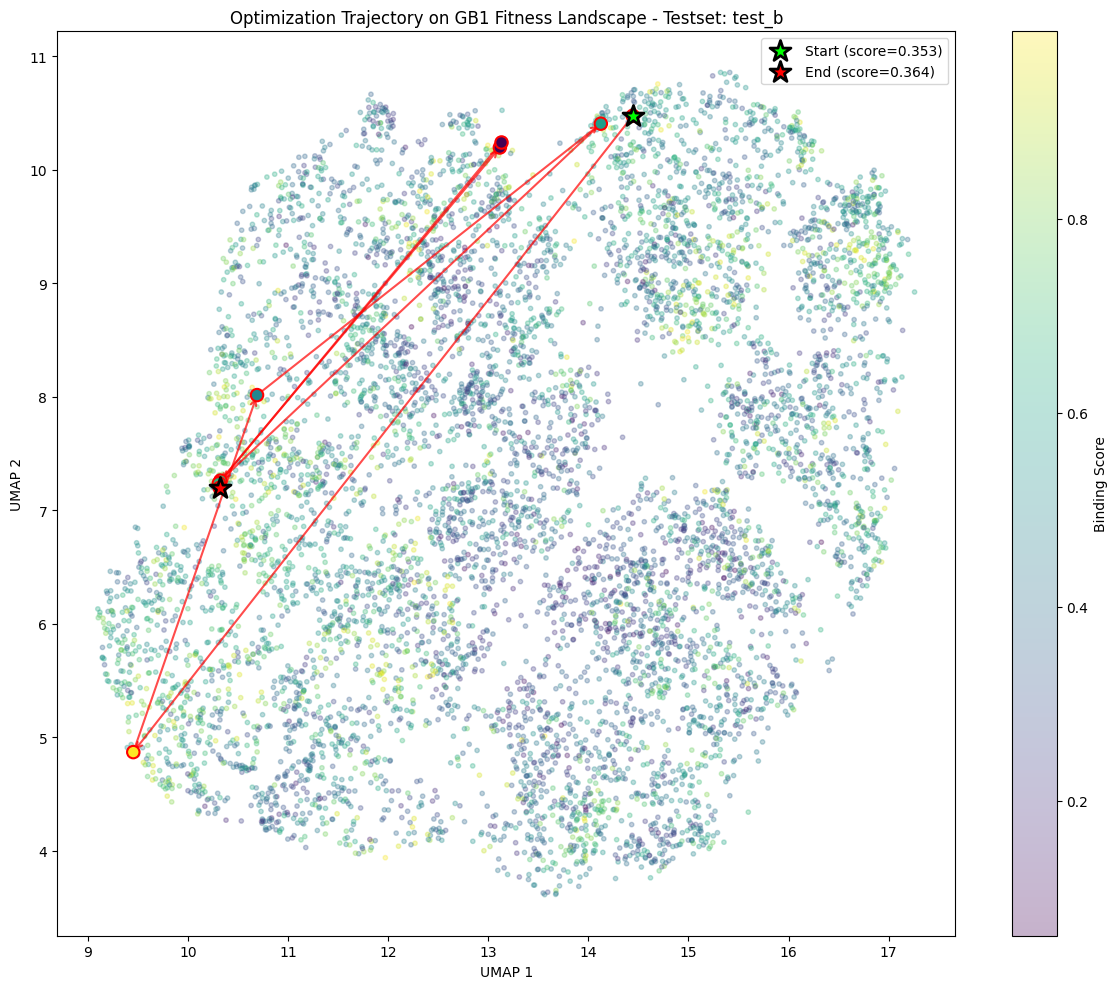

In [16]:
#test_b_df['mutation'] = test_b_df['mutation'].apply(
#    lambda seq: tf.one_hot(list(seq), depth=4).numpy().flatten()
#)
plot_umap_embedding(df, 'test_b', test_b_df, vocab_size=4)

Number of sequences not found in oracle: 20
Spearman Correlation: -0.0356


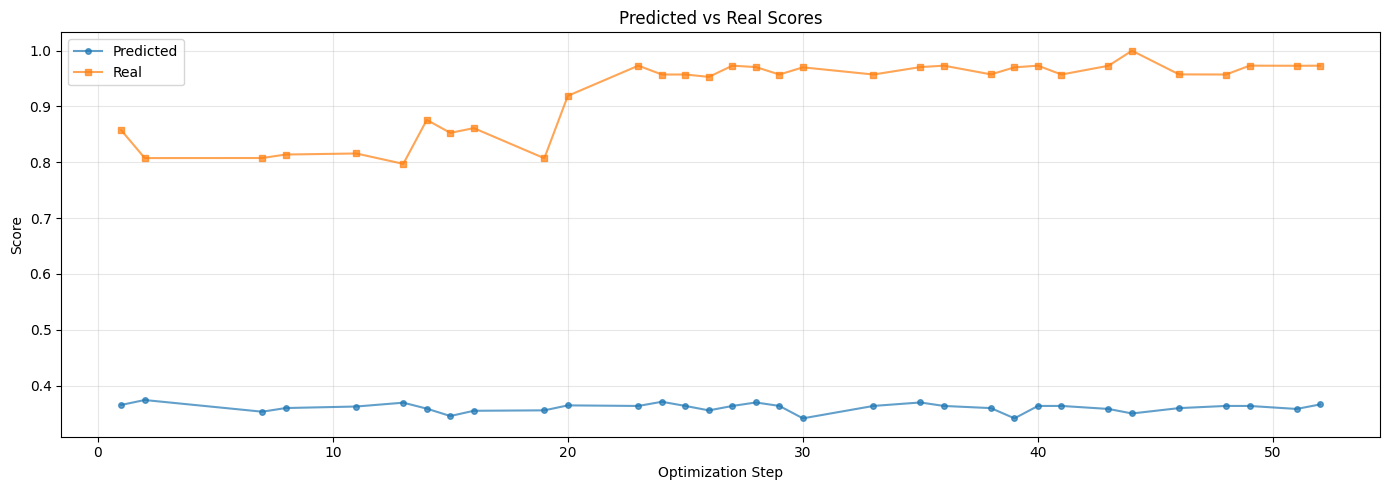

In [17]:
values_copy = values_df.copy()
values_copy.drop(columns=['real_score'], errors='ignore', inplace=True) # Drop real_score if it already exists to avoid confusion
test_c_oracle = build_oracle_df(df[df['split'] == 'test_c'])
test_c_df = lookup_oracle_testset(values_copy, test_c_oracle)
test_c_df = test_c_df.dropna(subset=['real_score'], inplace=False)
plot_results(test_c_df)

/var/folders/_2/6p52z75d21dc91tc6ss7n6w80000gn/T/ipykernel_5198/2665538143.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test_c_df['mutation'] = test_c_df['mutation'].apply(
/Users/meier/Documents/PracticalWork/.venv/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


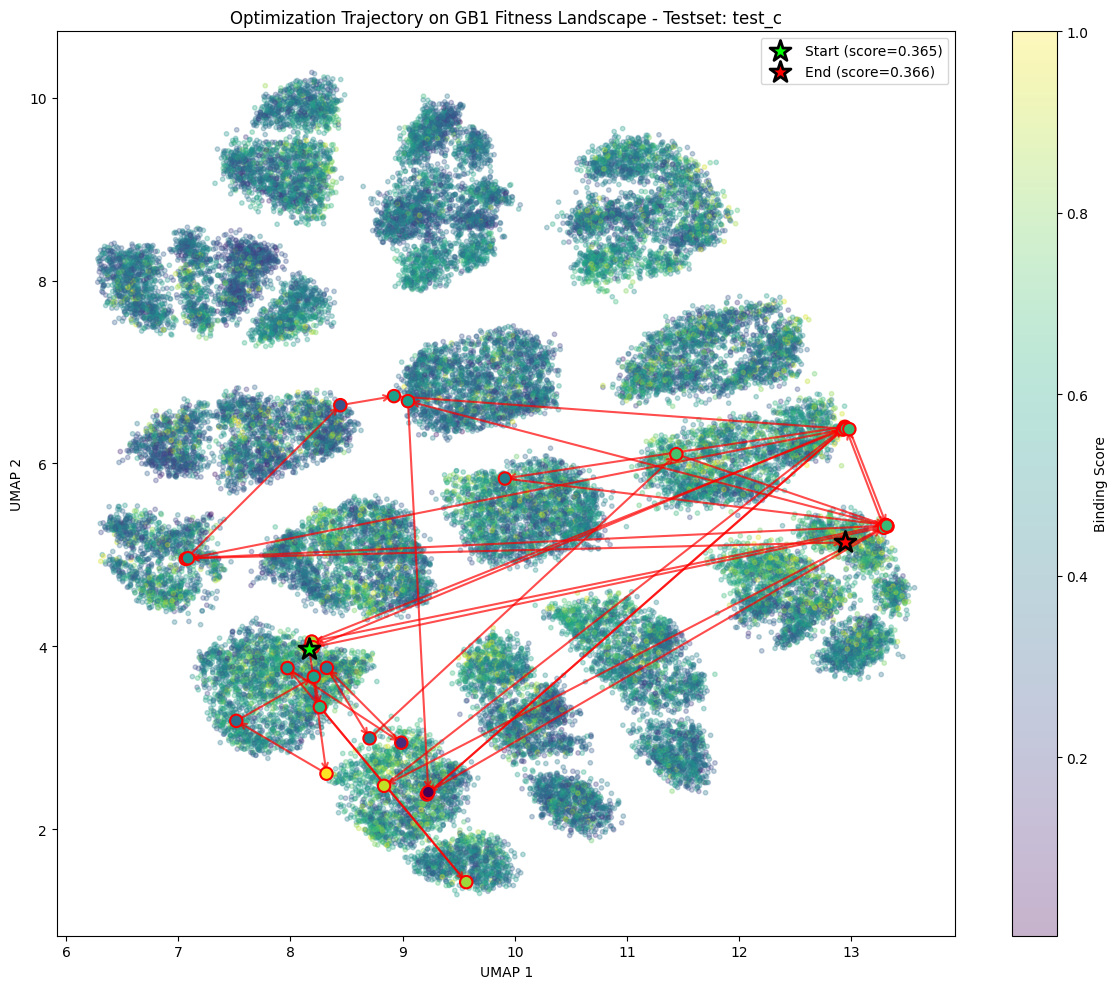

In [18]:
test_c_df['mutation'] = test_c_df['mutation'].apply(
    lambda seq: tf.one_hot(list(seq), depth=4).numpy().flatten()
)

plot_umap_embedding(df, 'test_c', test_c_df, vocab_size=4)

### GB-1 Dataset

In [ ]:
# Load dataset: GB1

import ast
df = pd.read_csv('GB1_data/dataframe.csv')
df.head()
df['encoded_sequence'] = df['encoded_sequence'].apply(ast.literal_eval)

# Create train Data 
train_df = df[df['split'] == 'train']

# print stats about train split
print("Original train split stats:")
print(train_df['binding_scores'].describe())

# === EMPHASIZE EXTREMES: Oversample top and bottom 20% ===
def create_extreme_emphasized_data(df, extreme_percentile=20, oversample_factor=5):
    """Oversample the extreme fitness values (top and bottom percentiles)."""
    df = df.copy()
    
    low_threshold = np.percentile(df['binding_scores'], extreme_percentile)
    high_threshold = np.percentile(df['binding_scores'], 100 - extreme_percentile)
    
    # Split into low, middle, high
    df_low = df[df['binding_scores'] <= low_threshold]
    df_high = df[df['binding_scores'] >= high_threshold]
    df_middle = df[(df['binding_scores'] > low_threshold) & (df['binding_scores'] < high_threshold)]
    
    print(f"Low fitness (bottom {extreme_percentile}%): {len(df_low)} sequences, scores <= {low_threshold:.2f}")
    print(f"High fitness (top {extreme_percentile}%): {len(df_high)} sequences, scores >= {high_threshold:.2f}")
    print(f"Middle: {len(df_middle)} sequences")
    
    # Oversample extremes
    df_low_oversampled = df_low.sample(n=len(df_low) * oversample_factor, replace=True, random_state=SEED)
    df_high_oversampled = df_high.sample(n=len(df_high) * oversample_factor, replace=True, random_state=SEED)
    
    # Combine
    emphasized_df = pd.concat([df_low_oversampled, df_middle, df_high_oversampled], ignore_index=True)
    return emphasized_df.sample(frac=1, random_state=SEED).reset_index(drop=True)  # Shuffle

# Create emphasized version
emphasized_train_df = create_extreme_emphasized_data(train_df, extreme_percentile=20, oversample_factor=3)

print("\nEmphasized training data stats:")
print(emphasized_train_df['binding_scores'].describe())
print(f"\nOriginal size: {len(train_df)}, Emphasized size: {len(emphasized_train_df)}")

# Use emphasized data for training
x = np.array(emphasized_train_df['encoded_sequence'].tolist())
y = emphasized_train_df['binding_scores'].values

X_train, X_val, y_train, y_val = train_test_split(x, y, test_size=0.1, random_state=SEED)
# One hot encoding
X_train_onehot = tf.one_hot(X_train, depth=20).numpy()
X_val_onehot = tf.one_hot(X_val, depth=20).numpy()

print(f"\nTraining set shape: {X_train_onehot.shape}")
print(f"Training labels range: [{y_train.min():.2f}, {y_train.max():.2f}]")


In [ ]:
# Load the oracle
oracle = mlp_oracle.MLPOracle(input_size=1100, output_size=1, hidden_size=128)
oracle.load_model('models/oracle_mlp.pth')

print(X_val_onehot[0].flatten().shape)

sequence = torch.tensor(X_val_onehot[0].flatten(), dtype=torch.float32)  # Shape: (1, 1100)
prediction = oracle.inference(sequence)
print(f"Predicted binding score: {prediction.item():.4f}, True binding score: {y_val[0]:.4f}")

In [ ]:
## === RL-LSTM Loop with Oracle Feedback ===

# 1. Pretrain RF
rf = RandomForestPredictor()
rf.train(X_train, y_train, n_estimators=500, max_depth=None, max_features=0.5, min_samples_leaf=3, min_samples_split=10)
rf.evaluate(X_val, y_val)

In [ ]:

from torch.utils.data import Dataset, DataLoader, TensorDataset

X_train_tensor = torch.LongTensor(X_train)
y_train_tensor = torch.FloatTensor(y_train).view(-1, 1)

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

# 2. Pretrain LSTM
model = LSTMGoalDirected(vocab_size=20, embedding_dim=16, seq_len=55, hidden_dim=64)
#train_goal_directed_model(model, train_loader, epochs=50, lr=0.001)


In [ ]:
model.save_model('models/lstm_goal_directed_GB1-pretrained.pth')

In [ ]:
# 3. RL Loop
model = LSTMGoalDirected(vocab_size=20, embedding_dim=16, seq_len=55, hidden_dim=64)
model.load_model('models/lstm_goal_directed_GB1-pretrained.pth')


values = rl_loop(model, rf, oracle, num_iterations=6, batch_size=128, X_train=X_train, y_train=y_train, GB1=True)
values_df = pd.DataFrame(values)
values_df.head()
plot_results(values_df)

In [ ]:
values_df['mutation'] = values_df['mutation'].apply(
    lambda seq: tf.one_hot(list(seq), depth=20).numpy().flatten()
)


plot_umap_embedding(df, 'test_a', values_df)

In [ ]:
plot_umap_embedding(df, 'test_b', values_df)

In [ ]:
plot_umap_embedding(df, 'test_c', values_df)